In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
plt.ion()

# **An introduction to matplotlib**

## **The basics**

In [4]:
plt.isinteractive()

True

> **Important note :** The `%matplotlib inline` magic embeds static images of the plot into our notebook. Another common option is the `%matplotlib notebook` magic. It provides a small level of interactivity to the plot by allowing actions such as resizing and zooming, though note that this requires some additional setup if you're using JupyterLab and can lead to some confusing bugs, depending on the code that's running in the notebook.

In [8]:
fb_df = pd.read_csv(
    '../Datasets/fb_2018.csv',
    index_col='date',
    parse_dates=True,
).convert_dtypes('numpy_nullable')

fb_df.dtypes

open      Float64
high      Float64
low       Float64
close     Float64
volume      Int64
dtype: object

In [9]:
fb_df.index.dtype

dtype('<M8[ns]')

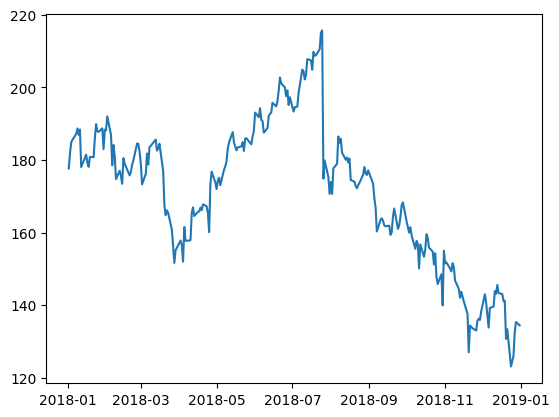

In [10]:
plt.plot(fb_df.index, fb_df.open)

plt.show()

In [14]:
%matplotlib inline

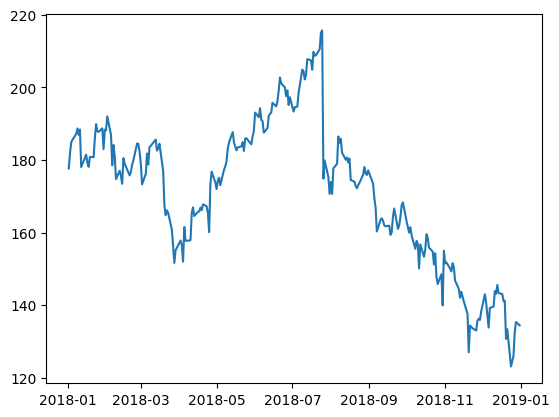

In [16]:
plt.plot(fb_df.index, fb_df.open)

plt.show()

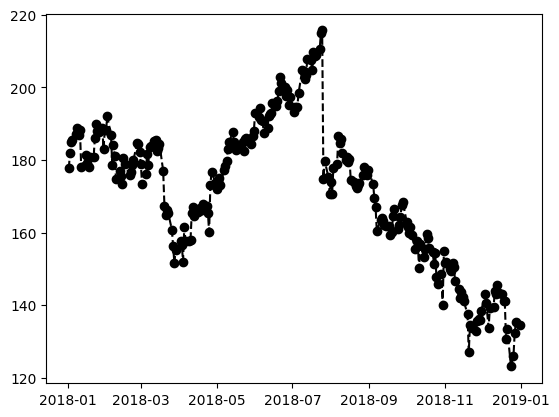

In [23]:
                    # '[marker][linestyle][color]'
plt.plot(fb_df.index, 'open', 'o--k', data=fb_df)

plt.show()

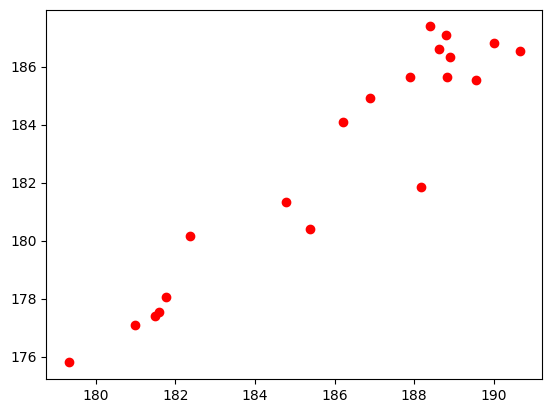

In [25]:
plt.plot('high', 'low', 'or', data=fb_df.head(20))

plt.show()

![Styling shortcuts for matplotlib](../Images/Styling_shortcuts_for_matplotlib.png)

In [26]:
quakes_df = pd.read_csv(
    '../Datasets/earthquakes.csv',
    dtype_backend='numpy_nullable'
)

quakes_df.dtypes

alert      string[python]
cdi               Float64
code       string[python]
detail     string[python]
dmin              Float64
felt              Float64
gap               Float64
ids        string[python]
mag               Float64
magType    string[python]
mmi               Float64
net        string[python]
nst               Float64
place      string[python]
rms               Float64
sig                 Int64
sources    string[python]
status     string[python]
time                Int64
title      string[python]
tsunami             Int64
type       string[python]
types      string[python]
tz                Float64
updated             Int64
url        string[python]
dtype: object

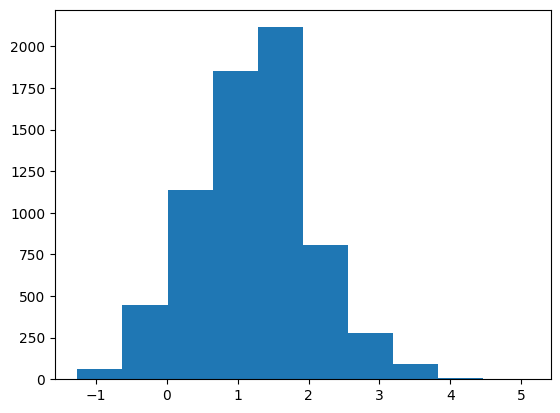

In [28]:
plt.hist(quakes_df.query('magType == "ml"').mag)

plt.show()

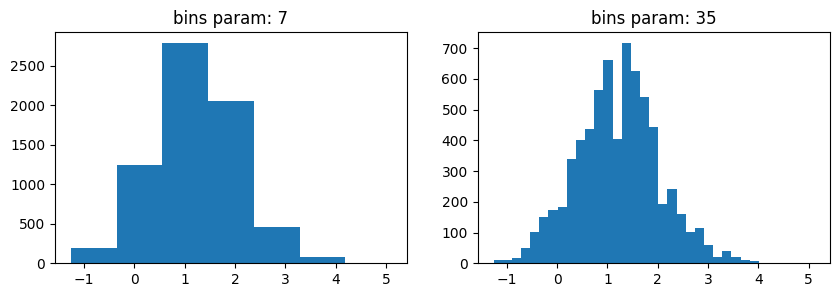

In [32]:
x = quakes_df.query('magType == "ml"').mag

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

for ax, bins in zip(axes, [7, 35]):
    ax.hist(x, bins=bins)
    ax.set_title(f"bins param: {bins}")

plt.show()

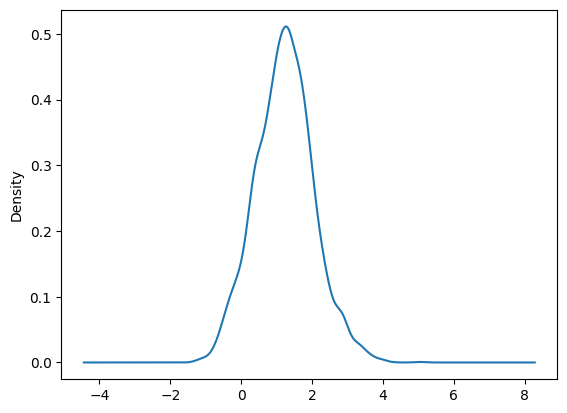

In [35]:
x.plot(kind='kde')

plt.show()

## **Plot components**

In [36]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

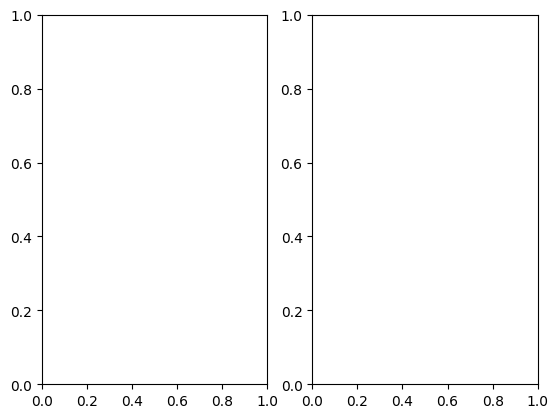

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2)

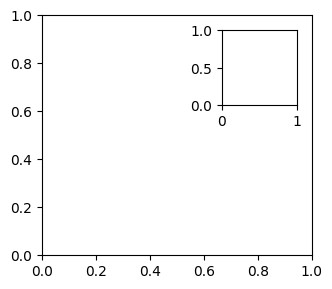

In [42]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.8])
inside = fig.add_axes([0.7, 0.6, 0.25, 0.25])

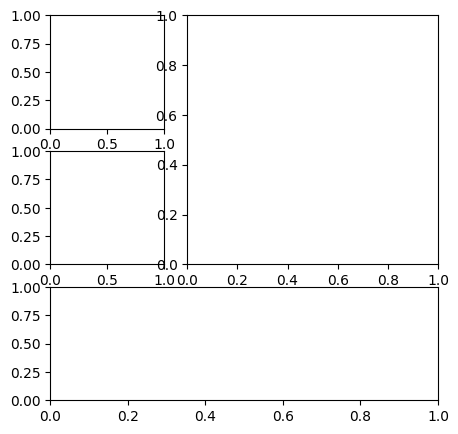

In [46]:
fig = plt.figure(figsize=(5, 5))
gs = fig.add_gridspec(nrows=3, ncols=3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2, :])

In [47]:
fig.savefig("empty_figure.png")

In [48]:
plt.close('all')

## **Additional options**

In [49]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

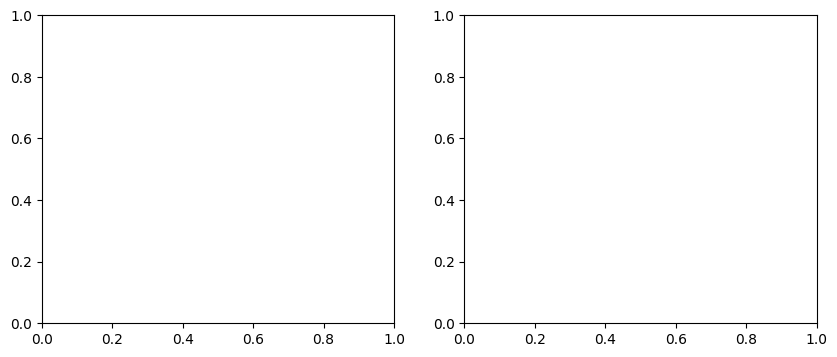

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

In [58]:
import random
import matplotlib as mpl

In [64]:
rcparams_list = list(mpl.rcParams.keys())
random.seed(20)
random.shuffle(rcparams_list)

sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

In [66]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [68]:
mpl.rcParams['figure.figsize'] = (300, 10)

mpl.rcParams['figure.figsize']

[300.0, 10.0]

In [69]:
mpl.rcdefaults()

mpl.rcParams['figure.figsize']

[6.4, 4.8]

In [70]:
mpl.rc('figure', figsize=(20, 20))

mpl.rcParams['figure.figsize']

[20.0, 20.0]

In [71]:
mpl.rcdefaults()

mpl.rcParams['figure.figsize']

[6.4, 4.8]

> **Tip :** If we find ourselves making the same changes every time we start Python, we should look into reading our configuration in rather than updating the default values each time. Consult the `mpl.rc_file()` function for more information.

# **Plotting with pandas**